## AG2

Setup and Import

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()
from autogen import ConversableAgent, AssistantAgent, UserProxyAgent, GroupChat, GroupChatManager
from autogen.llm_config import LLMConfig
import json
import time
import random

In [9]:
config_list = [
    {
        "model": "llama-3.3-70b-versatile",   # or any Groq-supported model
        "api_key": os.getenv("GROQ_API_KEY"),
        "base_url": "https://api.groq.com/openai/v1"
    }
]

### <b>Agent Concept

<b>Conversable Agent

It is the fundamental building block of AG2, designed to enbal seamless communication between AI entities. This core agent type handles message exchange and response generation, serving as the base class for all agents in the framework.<br>
Key Characterstic:<br>
1. Communication
2. Processing
3. Personality
4. Flexibility

In [11]:
from autogen import ConversableAgent

# LLM configuration (API key will be taken from environment variable)
llm_config = {
    "config_list": config_list
}

# student agent
student = ConversableAgent(
    name="Student",
    system_message="You are a student who is learning about AG2. You are curious and eager to learn.",
    human_input_mode = "NEVER",
    llm_config = llm_config)

# tutor agent
tutor = ConversableAgent(
    name="Tutor",
    system_message="You are a tutor who is teaching a student about AG2. You are patient and knowledgeable.",
    human_input_mode = "NEVER",
    llm_config = llm_config
)

# start conversation
chat_result = student.initiate_chat(
    recipient = tutor,
    message="Can you explain what is neural network is ?",
    max_turns=2,
    summary_method = "reflection_with_llm"
)

print(chat_result.summary)

Student (to Tutor):

Can you explain what is neural network is ?

--------------------------------------------------------------------------------
[autogen.oai.client: 07-19 13:05:19] {734} WARNING - Model llama-3.3-70b-versatile is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Tutor (to Student):

I'd be happy to explain what a neural network is.

A neural network is a type of machine learning model inspired by the structure and function of the human brain. It's a complex system composed of many interconnected nodes or "neurons" that process and transmit information.

**Basic Components:**

1. **Artificial Neurons (Nodes)**: These are the basic building blocks of a neural network. Each node receives one or more inputs, performs a computation on those inputs, and then sends the output to other nodes.
2. **Connections (Edges)**: These are the links between nodes, which allow them to 

<b>Creating Specialized Agent


In [13]:
# create a technical expert agent
tech_expert = ConversableAgent(
    name="TechExpert",
    system_message="""You are a senior software engineer with expertise in Python, AI, and system design.
    Provide technical, detailed explanations with code examples when appropriate.
    Always consider best practices and performance implications.""",
    llm_config = llm_config,
    human_input_mode = "NEVER"
)

# creating a creative writer agent
creative_Writer = ConversableAgent(
    name="CreativeWriter", 
    system_message="""You are a creative writer with expertise in storytelling, character development, and narrative structure.
    Provide imaginative and engaging content, and always consider the emotional impact of your writing.""",
    llm_config = llm_config,
    human_input_mode = "NEVER"
)

# Create a buisnedd analyst agent
business_analyst = ConversableAgent(
    name="BusinessAnalyst",
    system_message="""You are a business analyst with expertise in market research, data analysis, and strategic planning.
    Provide insights and recommendations based on data, and always consider the business implications of your analysis.""",
    llm_config = llm_config,
    human_input_mode = "NEVER"
)   
agent = [tech_expert, creative_Writer, business_analyst]

print("Starting group chat among agents...")


Starting group chat among agents...


<b>Built-in Agent Types


AG2 provide specializedd agent classes built on ConversableAgent to stream common workflows such as task-solving, tool use, and user interaction<br>
1. Assistant Agent --- Task Solving LLM assistant
2. UserProxyAgent --- Executing code on behalf of the user

user_proxy (to assistant):

Plot a sine wave using matplotlib from -2π to 2π and save the plot as sine_wave.png.

--------------------------------------------------------------------------------
[autogen.oai.client: 07-19 13:12:06] {734} WARNING - Model llama-3.3-70b-versatile is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
assistant (to user_proxy):

**Plotting a Sine Wave using Matplotlib**

Below is a Python code snippet that uses matplotlib to plot a sine wave from -2π to 2π and save the plot as `sine_wave.png`.

```python
import matplotlib.pyplot as plt
import numpy as np

def plot_sine_wave():
    # Generate x values from -2π to 2π
    x = np.linspace(-2 * np.pi, 2 * np.pi, 400)

    # Calculate corresponding y values (sine of x)
    y = np.sin(x)

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label='Sine Wave')

    # Add title and labels
    plt.t

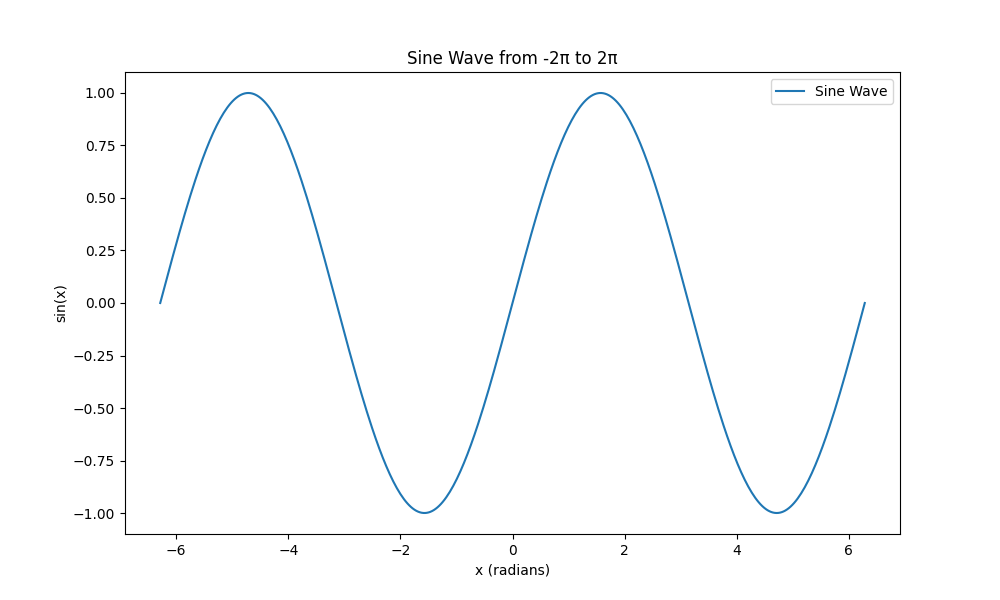


Final Summary:
If you're ready to proceed, please provide the text or topic you'd like to discuss, and I'll do my best to assist you.


In [14]:
from autogen.coding import LocalCommandLineCodeExecutor


# Step 2: Create assistant agent
assistant = AssistantAgent(
    name="assistant",
    system_message="You are a helpful assistant who writes and explains Python code clearly.",
    llm_config=llm_config
)

# Step 3: Create user proxy agent
user_proxy = UserProxyAgent(
    name="user_proxy",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=5,
    code_execution_config={
        "executor": LocalCommandLineCodeExecutor(work_dir="coding", timeout=30),
    },
)

# Step 4: Start task
chat_result = user_proxy.initiate_chat(
    recipient=assistant,
    message="Plot a sine wave using matplotlib from -2π to 2π and save the plot as sine_wave.png.",
    max_turns=4,
    summary_method="reflection_with_llm"
)

# Step 5: Display image
from IPython.display import Image, display
import os

image_path = "coding/sine_wave.png"
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print("Plot not found.")

# Step 6: Print summary
print("\nFinal Summary:")
print(chat_result.summary)

<b>Human-in-the-loop

In [15]:
import random

# Step 1: Define system message
triage_system_message = """
You are a bug triage assistant. You will be given bug report summaries.

For each bug:
- If it is urgent (e.g., 'crash', 'security', or 'data loss' is mentioned), escalate it and ask the human agent for confirmation.
- If it seems minor (e.g., cosmetic, typo), suggest closing it but still ask for human review.
- Otherwise, classify it as medium priority and ask the human for review.

Once all bugs are processed, summarize what was escalated, closed, or marked as medium priority.
End by saying: "You can type exit to finish."
"""

# Step 2: Create assistant agent
triage_bot = ConversableAgent(
    name="triage_bot",
    system_message=triage_system_message,
    llm_config=llm_config
)

# Step 3: Create human agent
human = ConversableAgent(
    name="human",
    human_input_mode="ALWAYS",
)

# Step 4: Generate sample bugs
BUGS = [
    "App crashes when opening user profile.",
    "Minor UI misalignment on settings page.",
    "Password reset email not sent consistently.",
    "Typo in the About Us footer text.",
    "Database connection timeout under heavy load.",
    "Login form allows SQL injection attack.",
]

random.shuffle(BUGS)
selected_bugs = BUGS[:3]

# Step 5: Format prompt
initial_prompt = (
    "Please triage the following bug reports one by one:\n\n" +
    "\n".join([f"{i+1}. {bug}" for i, bug in enumerate(selected_bugs)])
)

# Step 7: Start conversation
human.initiate_chat(
    recipient=triage_bot,
    message=initial_prompt,
)

human (to triage_bot):

Please triage the following bug reports one by one:

1. Database connection timeout under heavy load.
2. App crashes when opening user profile.
3. Login form allows SQL injection attack.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 07-19 13:13:32] {734} WARNING - Model llama-3.3-70b-versatile is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
triage_bot (to human):

Let's start with the first bug report:

1. Database connection timeout under heavy load.
This bug seems to be related to performance under heavy load, but it doesn't mention a crash, security issue, or data loss. I would classify it as medium priority and ask the human for review.

Moving on to the next one:

2. App crashes when opening user profile.
This bug report mentions an app crash, which is an urgent issue

ChatResult(chat_id=252122801820662611157809014074862268866, chat_history=[{'content': 'Please triage the following bug reports one by one:\n\n1. Database connection timeout under heavy load.\n2. App crashes when opening user profile.\n3. Login form allows SQL injection attack.', 'role': 'assistant', 'name': 'human'}, {'content': "Let's start with the first bug report:\n\n1. Database connection timeout under heavy load.\nThis bug seems to be related to performance under heavy load, but it doesn't mention a crash, security issue, or data loss. I would classify it as medium priority and ask the human for review.\n\nMoving on to the next one:\n\n2. App crashes when opening user profile.\nThis bug report mentions an app crash, which is an urgent issue. I would escalate it and ask the human agent for confirmation.\n\nNext one:\n\n3. Login form allows SQL injection attack.\nThis bug report mentions a security issue, specifically an SQL injection attack. This is also an urgent issue. I would e

<b>Agent Orchestration & Multip Agent System in AG2


<b>1. Group Chat

In [ ]:
from autogen import ConversableAgent, GroupChat, GroupChatManager

planner_message = "Create a short lesson plan for the 4th grader"
reviewer_message = "Please review the lesson plan and provide feedback for improvement."
teacher_message = "Please provide a detailed lesson plan for the 4th grader, including objectives, activities, and assessment methods." 

# creating agents
lesson_planner = ConversableAgent(
    name="LessonPlanner",
    system_message=planner_message,
    description="You are a lesson planner who creates lesson plans for students. You are creative and knowledgeable about teaching methods.",
    llm_config=llm_config
)
lesson_reviewer = ConversableAgent(
    name="LessonReviewer",
    system_message=reviewer_message,
    description="You are a lesson reviewer who reviews lesson plans and provides feedback for improvement. You are critical and knowledgeable about teaching methods.",
    llm_config=llm_config
)
lesson_teacher = ConversableAgent(
    name="LessonTeacher",
    system_message=teacher_message,
    description="You are a lesson teacher who teaches students based on the lesson plan. You are patient and knowledgeable about teaching methods.",
    llm_config=llm_config
)

groupchat = GroupChat(

    agents=[lesson_planner, lesson_reviewer, lesson_teacher],
    speaker_selection_method="auto"

)

manager  = GroupChatManager(name="LessonPlanManager", groupchat=groupchat, llm_config=llm_config)

# start chat
lesson_teacher.initiate_chat(
    recipient=manager,
    message="Please create a lesson plan for the 4th grader on the topic of 'The Water Cycle'.",
    max_turns=5,
    summary_method="reflection_with_llm"
)

<b>Tools And Execution

In [23]:
from autogen import ConversableAgent, register_function
from typing import Annotated

def is_prime(n: Annotated[int, "Positive integer"]) -> str:
    if n < 2:
        return f"{n} is not a prime number."
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return f"{n} is not a prime number."
    return f"{n} is a prime number."

# Creating agents
math_asker = ConversableAgent(
    name = "math_asker",
    system_message = "You are a math enthusiast who asks questions about prime numbers.",
    llm_config = llm_config
)

math_checker = ConversableAgent(
    name = "math_checker",
    human_input_mode = "NEVER",
    llm_config = llm_config
)

# register function
register_function(is_prime, caller = math_asker, executor = math_checker, description = "Check if a number is prime. Returns yes or no.")

# start conversation
math_checker.initiate_chat(
    recipient = math_asker,
    message = "Is 29 a prime number?",
    max_turns = 2,

)

math_checker (to math_asker):

Is 29 a prime number?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 07-19 13:26:48] {734} WARNING - Model llama-3.3-70b-versatile is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
math_asker (to math_checker):

***** Suggested tool call (9gfaj0fvk): is_prime *****
Arguments: 
{"n":29}
*****************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION is_prime...
Call ID: 9gfaj0fvk
Input arguments: {'n': 29}

>>>>>>>> EXECUTED FUNCTION is_prime...
Call ID: 9gfaj0fvk
Input arguments: {'n': 29}
Output:
29 is a prime number.
math_checker (to math_asker):

***** Response from calling tool (9gfaj0fvk) *****
29 is a prime number.
*************************************************

ChatResult(chat_id=94203639969893350377408965248176488875, chat_history=[{'content': 'Is 29 a prime number?', 'role': 'assistant', 'name': 'math_checker'}, {'tool_calls': [{'id': '9gfaj0fvk', 'function': {'arguments': '{"n":29}', 'name': 'is_prime'}, 'type': 'function'}], 'content': None, 'role': 'assistant'}, {'content': '29 is a prime number.', 'tool_responses': [{'tool_call_id': '9gfaj0fvk', 'role': 'tool', 'content': '29 is a prime number.'}], 'role': 'tool', 'name': 'math_checker'}, {'tool_calls': [{'id': 'rmzfrttfh', 'function': {'arguments': '{"n":29}', 'name': 'is_prime'}, 'type': 'function'}], 'content': None, 'role': 'assistant'}], summary='', cost={'usage_including_cached_inference': {'total_cost': 0, 'llama-3.3-70b-versatile': {'cost': 0, 'prompt_tokens': 520, 'completion_tokens': 25, 'total_tokens': 545}}, 'usage_excluding_cached_inference': {'total_cost': 0, 'llama-3.3-70b-versatile': {'cost': 0, 'prompt_tokens': 520, 'completion_tokens': 25, 'total_tokens': 545}}}, human

In AG2, register_function is used to expose a python function as a tool that can be executed by one agent on behalf of another. This enables agent to delegate tasks like computation, data processing, or external API calls.

It extend agent capabilities beyond text generation. It allow agnets to solve task through function execution and enable collabrate workflows between a caller and an executor agent.

this function as a parameter function, caller, executor and description.

In [24]:
# example
register_function(
    is_prime, 
    caller = math_asker,
    executor = math_checker,
    description = "Check if a number is prime. Returns yes or no."
)

c:\Users\HP\.virtualenvs\Intro_To_Rag-n9prH0y5\Lib\site-packages\autogen\agentchat\conversable_agent.py:3884: UserWarning: Function 'is_prime' is being overridden.
  warnings.warn(f"Function '{tool_sig['function']['name']}' is being overridden.", UserWarning)
c:\Users\HP\.virtualenvs\Intro_To_Rag-n9prH0y5\Lib\site-packages\autogen\agentchat\conversable_agent.py:3765: UserWarning: Function 'is_prime' is being overridden.
  warnings.warn(f"Function '{name}' is being overridden.", UserWarning)


<b>Structured Outputs

In [25]:
from pydantic import BaseModel, Field
from autogen import ConversableAgent

# Define structured output model
class TicketSummary(BaseModel):
    customer_name: str
    issue_type: str
    urgency_level: str
    recommended_action: str

# Create agent
support_agent = ConversableAgent(
    name="support_agent",
    system_message=(
        "You are a support assistant. Summarize a customer ticket using:"
        "\n- customer_name"
        "\n- issue_type (e.g. login issue, billing problem, bug report)"
        "\n- urgency_level (Low, Medium, High)"
        "\n- recommended_action"
    ),
    llm_config=llm_config
)

# Start conversation
support_agent.initiate_chat(
    recipient=support_agent,
    message="Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.",
    max_turns=1
)

support_agent (to support_agent):

Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 07-19 13:45:32] {734} WARNING - Model llama-3.3-70b-versatile is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
support_agent (to support_agent):

Here is a summary of the customer ticket:

* customer_name: John Doe
* issue_type: Login issue (password reset)
* urgency_level: High
* recommended_action: Expedite password reset assistance, potentially offering a temporary password or alternative login method to ensure John Doe can access the system in time for his meeting.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (fb5938e0-4065-4c16-9952-4d8152e87e21): Maximum turn

ChatResult(chat_id=111685152472178940973327824640298850948, chat_history=[{'content': 'Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.', 'role': 'assistant', 'name': 'support_agent'}, {'content': 'Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.', 'role': 'user', 'name': 'support_agent'}, {'content': 'Here is a summary of the customer ticket:\n\n* customer_name: John Doe\n* issue_type: Login issue (password reset)\n* urgency_level: High\n* recommended_action: Expedite password reset assistance, potentially offering a temporary password or alternative login method to ensure John Doe can access the system in time for his meeting.', 'role': 'assistant', 'name': 'support_agent'}, {'content': 'Here is a summary of the customer ticket:\n\n* customer_name: John Doe\n* issue_type: Login issue (password reset)\n* urgency_level: High\n* recommended_action: Expedite password reset assistance, potentially offe